# Import

In [10]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.notebook import tqdm  

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

In [11]:
from brighteyes_flim import mcs
from brighteyes_flim import flism
from brighteyes_flim.flism import Alignment

print(mcs.__file__)
print(flism.__file__)


/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/dataio/mcs.py
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/flism.py


# Imported helpers

In [12]:

IRF_from_data_deconvolution = Alignment.IRF_from_data_deconvolution
fit_model_data = Alignment.fit_model_data
hist_for_plot = Alignment.hist_for_plot
perform_fit_data = Alignment.perform_fit_data
#perform_fit_data_ng = Alignment.perform_fit_data_ng
phasor_delay_from_hist = Alignment.phasor_delay_from_hist

# Unit convention used below:
# - *_ns: nanoseconds
# - *_bins: histogram-bin shifts
# - *_rad: phase in radians
# - *_norm: normalized 0..1 phasor / fit amplitude


# Tests
It this thest we want to generate by simulation the data, the irf and the reference measurements. All of them with a different delay from the T/2 time point.


# Processing (Data and Reference) EXP

From here we assume that we have the Data (data_sim) and the Reference (ref_sim) datasets and we simply know that the Reference is a single-exponential decay from which we know the fluorescence lifetime tau_R

Given the fact that we know that the reference is a single-exponential decay and we know the lifetime tau_R, we can deconvolve the reference dataset to estimate irf for this specific measurement. We call it est_irf_ref to distinguish from the irf_sim, which is a simulated irf dataset, and irf which is the noise-free (and centered in T/2) irf used for all simulation

In [13]:
f_ref = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
tau_ref_ns = 2.5

f_data = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"


ref_data_6d, metadata_ref = mcs.load(f_ref)
data_hist_6d, metadata_data = mcs.load(f_data)

#print(a[1].dfd_activate)
#print(a[1].dfd_freq)
#print(a[1].dfd_nbins)

ref_hist_org = ref_data_6d[0, 0, :, :, :, 12].sum(axis=(0, 1))
data_hist = data_hist_6d[0, 0, :, :, :, 12].sum(axis=(0, 1))

ROLL BINS =  0
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


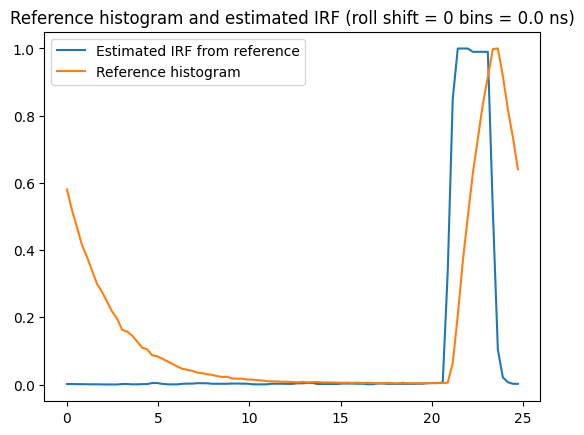

initial_dT_ns/nbin = 0.48131510945074035 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 22.16556263901608
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 0.13222942567328033 ns
Initial delay between data and reference = 0.48131510945074035 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(0.48131510945074035), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 1.4653334402890223
dT_fit_bins = 5.034678338640873
dT_fit_ns = 1.3831533897365038
tau_fit_ns = 1.5016250194877308
delay between data and reference from fit = 1.3831533897365038 ns


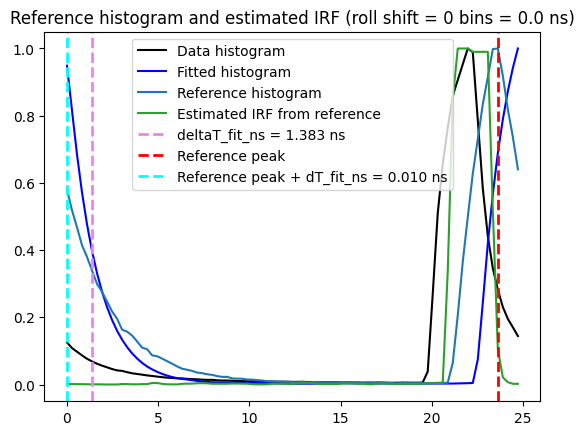

ROLL BINS =  10
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


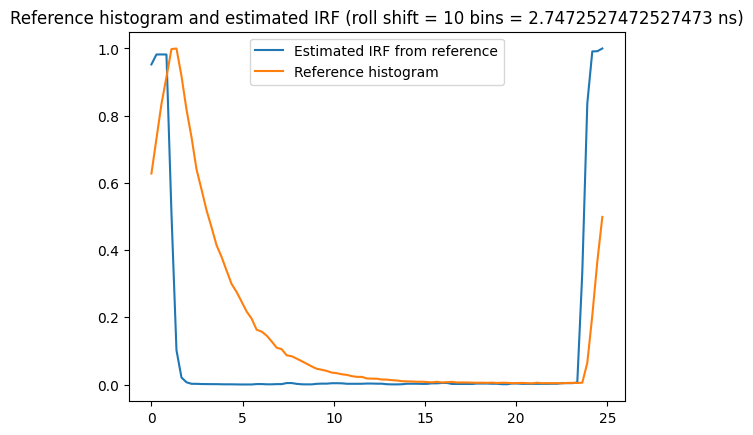

initial_dT_ns/nbin = -9.518006850020354 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 24.91262911139825
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = -2.614837046708889 ns
Initial delay between data and reference = -9.518006850020354 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(-9.518006850020354), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 0.12935796734580257
dT_fit_bins = 15.000103403817945
dT_fit_ns = 4.120907528521414
tau_fit_ns = 1.4210467982290578
delay between data and reference from fit = 4.120907528521414 ns


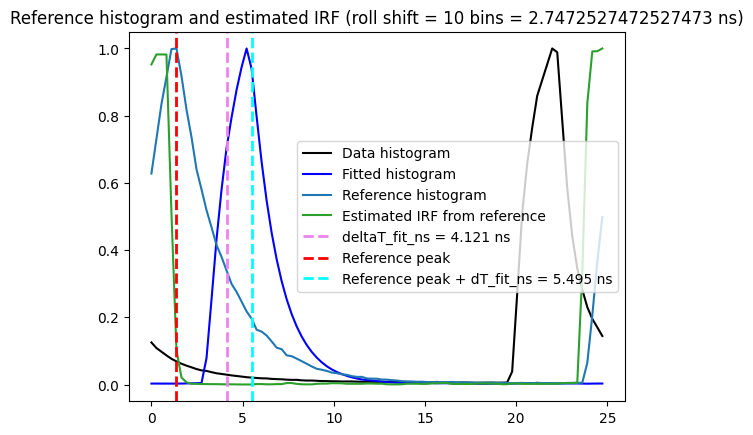

ROLL BINS =  37
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


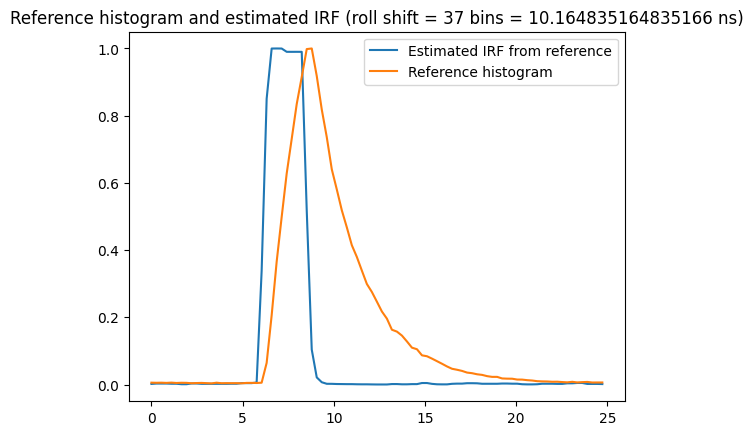

initial_dT_ns/nbin = 54.481309157305006 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 7.330399439056115
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 14.967392625633245 ns
Initial delay between data and reference = 54.481309157305006 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(54.481309157305006), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 1485.4167296294127
dT_fit_bins = -45.4999999996763
dT_fit_ns = -12.499999999911072
tau_fit_ns = 4.65847077050162
delay between data and reference from fit = 12.500000000088928 ns


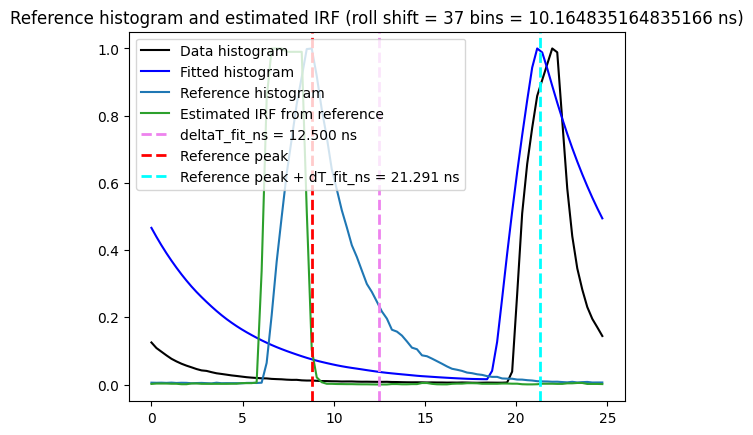

ROLL BINS =  38
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


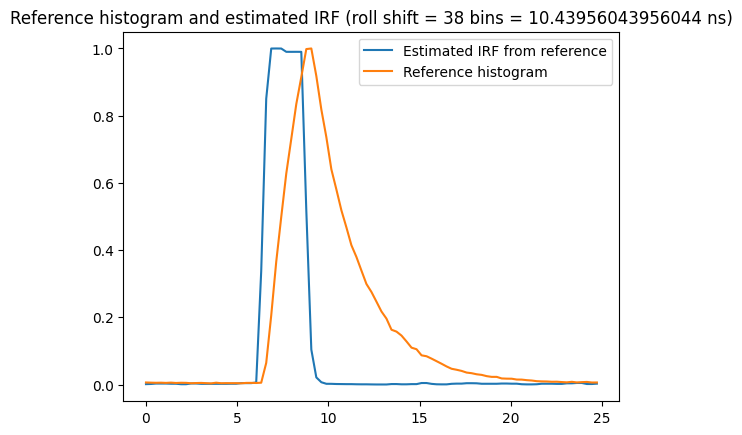

initial_dT_ns/nbin = 53.48132602769008 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 7.605120079060216
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 14.692671985629145 ns
Initial delay between data and reference = 53.48132602769008 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(53.48132602769008), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 72.99775732396056
dT_fit_bins = -45.499279821347464
dT_fit_ns = -12.499802148721832
tau_fit_ns = 3.5450662871178222
delay between data and reference from fit = 12.500197851278168 ns


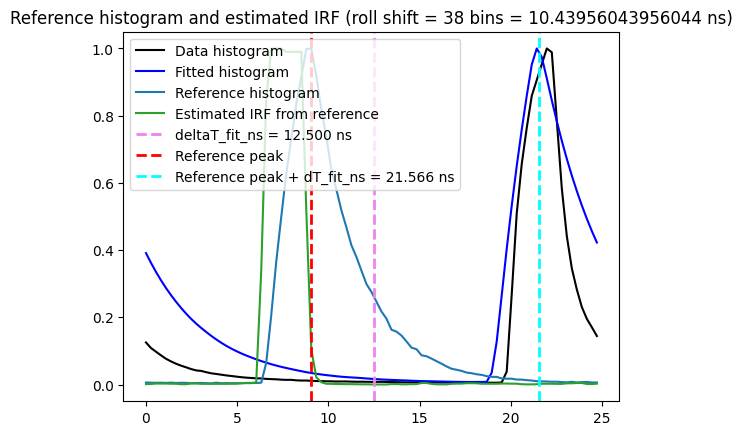

ROLL BINS =  39
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


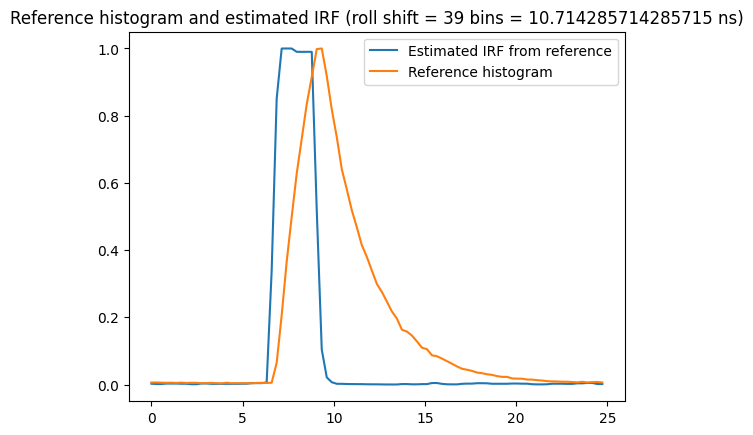

initial_dT_ns/nbin = 52.48133077996661 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 7.879844048215015
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 14.417948016474345 ns
Initial delay between data and reference = 52.48133077996661 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(52.48133077996661), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 49.056411339128246
dT_fit_bins = -45.49999999964325
dT_fit_ns = -12.499999999901993
tau_fit_ns = 2.490859723212588
delay between data and reference from fit = 12.500000000098007 ns


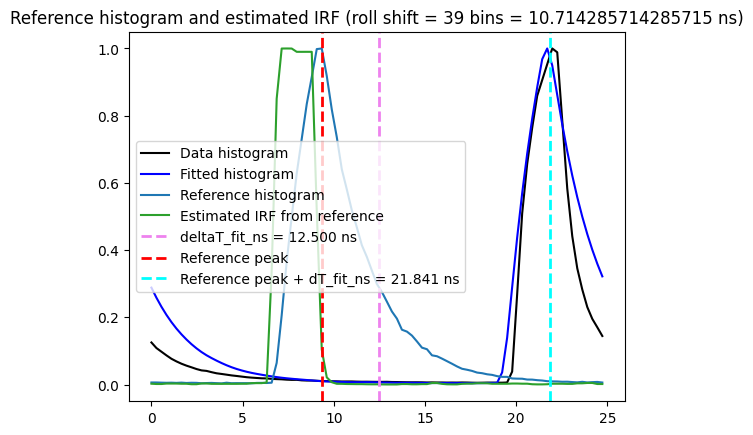

ROLL BINS =  40
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


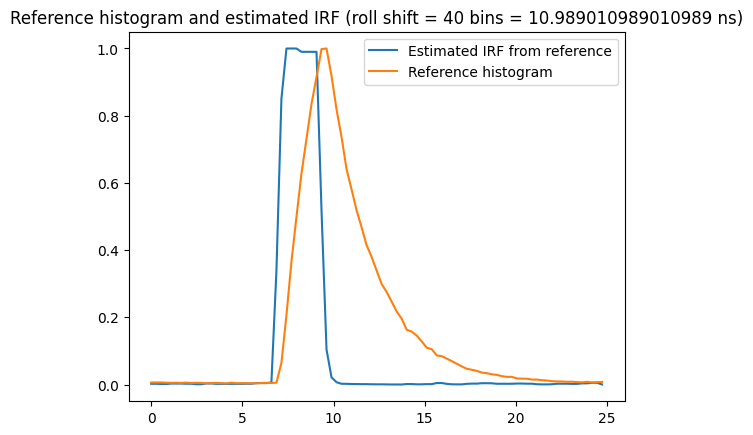

initial_dT_ns/nbin = 51.48129631731476 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 8.15457879070179
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 14.143213273987572 ns
Initial delay between data and reference = 51.48129631731476 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(51.48129631731476), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 108.38354375446931
dT_fit_bins = -45.49603822279235
dT_fit_ns = -12.49891159966823
tau_fit_ns = 1.7367404753326685
delay between data and reference from fit = 12.50108840033177 ns


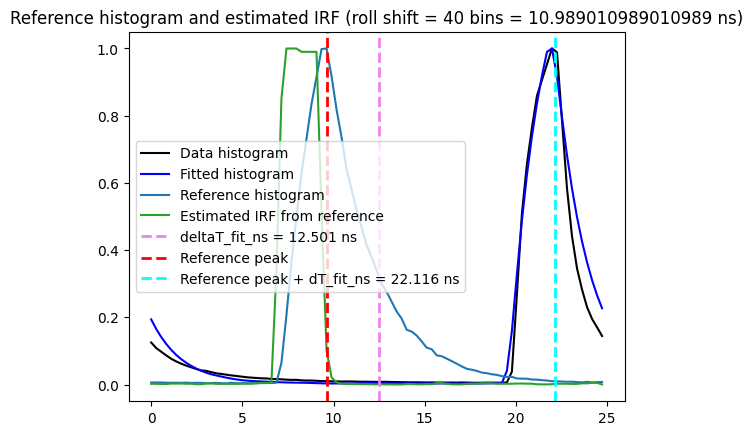

ROLL BINS =  41
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


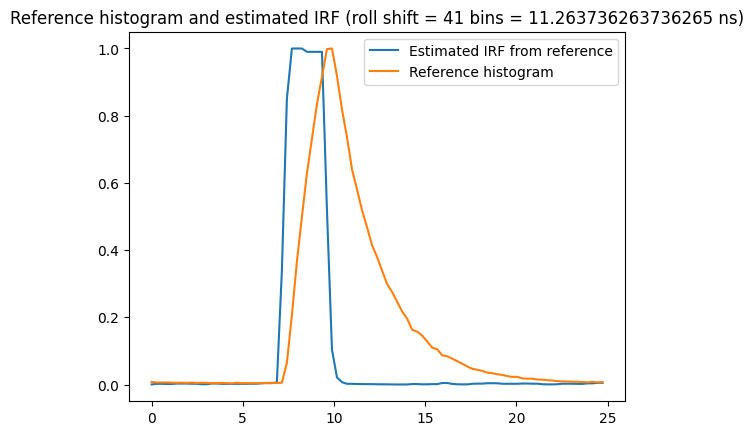

initial_dT_ns/nbin = 50.48129619839532 bins
delay_data_ns = 22.29779206468936
delay_irf_ns = 8.429304098097239
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 13.868487966592122 ns
Initial delay between data and reference = 50.48129619839532 bins
Using circular fit with curve_fit_circular
initial_guess [1.0, np.float64(50.48129619839532), 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}
C_fit_norm = 117.15003796516962
dT_fit_bins = -44.95134043624493
dT_fit_ns = -12.349269350616739
tau_fit_ns = 1.5102942383379794
delay between data and reference from fit = 12.650730649383261 ns


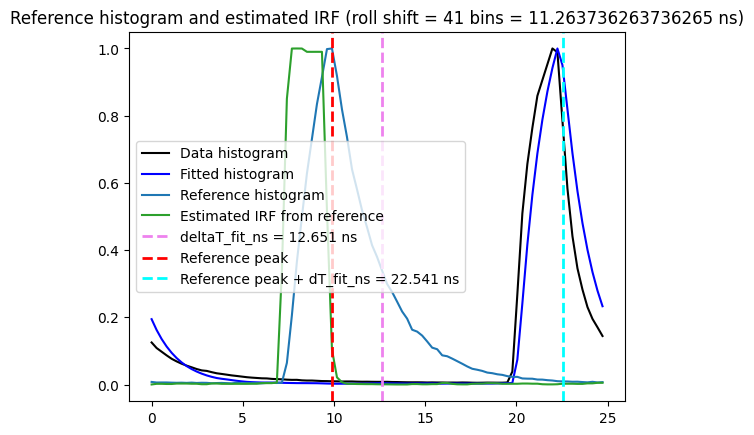

In [14]:
mode = "model_shift"
#mode = "irf_shift"
 


for ref_roll_bins in [0,10,] + list(range(37, 42, 1)):
    print("ROLL BINS = ", ref_roll_bins)
    #ref_roll_bins = 26
    ref_hist = np.roll(ref_hist_org, ref_roll_bins)

    nbin = metadata_data.dfd_nbins 
    excitation_freq_hz = metadata_data.dfd_freq * 1e6

    period_ns = 1 / excitation_freq_hz * 1e9
    dt_ns = period_ns / nbin
    t_ns = np.arange(nbin) * dt_ns
    C_ref = 1.
    print(f"dt_ns = {dt_ns} ns, period_ns = {period_ns} ns")


    print(f"ref_hist sum = {ref_hist.sum()} counts")
    print(f"ref_hist shape = {ref_hist.shape}")

    est_irf_ref = IRF_from_data_deconvolution(ref_hist, t_ns, C_ref, tau_ref_ns, period_ns, iterations=300) #, regularization=0)

    plt.plot(t_ns, est_irf_ref / max(est_irf_ref), label='Estimated IRF from reference')
    plt.plot(t_ns, ref_hist / max(ref_hist), label='Reference histogram')
    plt.title(f"Reference histogram and estimated IRF (roll shift = {ref_roll_bins} bins = {ref_roll_bins * dt_ns} ns)")
    plt.legend()
    plt.show()



    _, _, delay_data_ns = phasor_delay_from_hist(data_hist, period_ns)
    _, _, delay_irf_ns = phasor_delay_from_hist(est_irf_ref, period_ns)


    initial_dT_ns = delay_data_ns - delay_irf_ns # Add half bin to shift from bin edge to bin center convention.
    initial_dT_bins = initial_dT_ns / dt_ns
    
    print(f"initial_dT_ns/nbin = {initial_dT_ns / dt_ns} bins")
    print(f"delay_data_ns = {delay_data_ns}")
    print(f"delay_irf_ns = {delay_irf_ns}")
    print(f"nbin = {nbin}   bins, dt_ns = {dt_ns} ns")
    print(f"Initial delay between data and reference = {initial_dT_ns} ns")
    print(f"Initial delay between data and reference = {initial_dT_bins} bins")



    fit_result, fit_cov = perform_fit_data(
        t_ns,
        data_hist,
        est_irf_ref,
        period_ns,
        initial_dT=initial_dT_bins,
        #irf_min=0.5,
        mode=mode
    )
    C_fit_norm = fit_result["C"]
    dT_fit_bins = fit_result["dT"]
    tau_fit_ns = fit_result["tau"]
    dT_fit_ns = dT_fit_bins * dt_ns

    fitted_hist = fit_model_data(t_ns, C_fit_norm, dT_fit_bins, tau_fit_ns, 
                                 irf=est_irf_ref, period=period_ns, mode=mode)

    deltaT_fit_ns = np.mod(dT_fit_ns, period_ns)


    print(f"C_fit_norm = {C_fit_norm}")
    print(f"dT_fit_bins = {dT_fit_bins}")
    print(f"dT_fit_ns = {dT_fit_ns}")
    print(f"tau_fit_ns = {tau_fit_ns}")
    print(f"delay between data and reference from fit = {deltaT_fit_ns} ns")

    plt.figure()
    plt.plot(t_ns, data_hist / max(data_hist), label='Data histogram', color='black')
    plt.plot(t_ns, fitted_hist / max(fitted_hist), label='Fitted histogram', color='blue')

    plt.plot(t_ns, ref_hist / max(ref_hist), label='Reference histogram', color='tab:blue')
    plt.plot(t_ns, est_irf_ref / max(est_irf_ref), label='Estimated IRF from reference', color='tab:green')
    plt.title(f"Reference histogram and estimated IRF (roll shift = {ref_roll_bins} bins = {ref_roll_bins * dt_ns} ns)")
    plt.legend()

    plt.axvline(x=deltaT_fit_ns, linestyle='--', color='violet', linewidth=2, label=f"deltaT_fit_ns = {deltaT_fit_ns:.3f} ns")

    ref_peak_ns = np.mod(t_ns[ref_hist.argmax()], period_ns)
    plt.axvline(x=ref_peak_ns, linestyle='--', color='red', linewidth=2, label='Reference peak')

    fit_shifted_ref_peak_ns = np.mod(ref_peak_ns + deltaT_fit_ns, period_ns)
    plt.axvline(x=fit_shifted_ref_peak_ns, linestyle='--', color='cyan', linewidth=2, label=f"Reference peak + dT_fit_ns = {fit_shifted_ref_peak_ns:.3f} ns")
    plt.legend()
    plt.show()

Now we fit the Data dataset with the irf estimated from the reference

The fit parameter `dT_fit_bins` is a shift in histogram bins between the data histogram and the IRF/reference histogram. The equivalent in nanoseconds is `dT_fit_bins * dt_ns`.

IRF phase_rad = 2.1185 rad, phasor_norm = 0.9614, delay_ns = 8.4293 ns
DATA phase_rad = 5.6040 rad, phasor_norm = 0.8434, delay_ns = 22.2978 ns
Delta(DATA - IRF) = 13.8685 ns


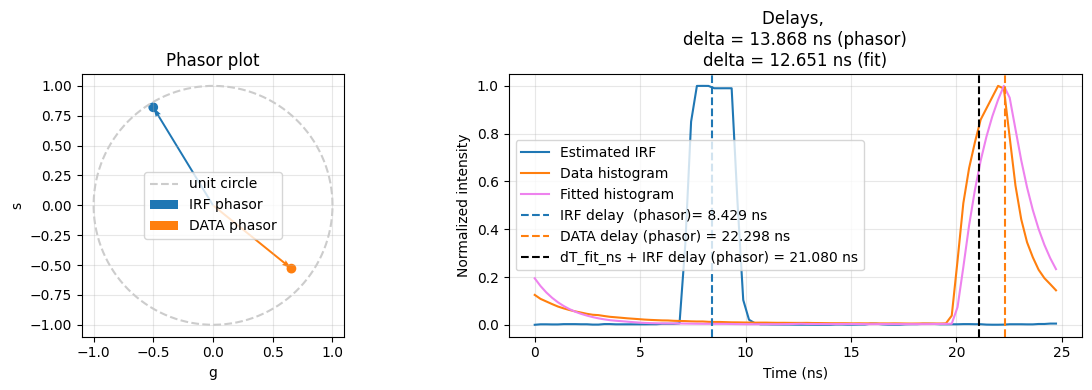

In [15]:
irf_hist = hist_for_plot(est_irf_ref)
data_hist = hist_for_plot(data_hist)

phasor_irf, phase_irf_rad, delay_irf_ns = phasor_delay_from_hist(irf_hist, period_ns)
phasor_data, phase_data_rad, delay_data_ns = phasor_delay_from_hist(data_hist, period_ns)
phasor_irf_norm = np.abs(phasor_irf)
phasor_data_norm = np.abs(phasor_data)
delta_delay_ns = np.mod(delay_data_ns - delay_irf_ns, period_ns)

print(f"IRF phase_rad = {phase_irf_rad:.4f} rad, phasor_norm = {phasor_irf_norm:.4f}, delay_ns = {delay_irf_ns:.4f} ns")
print(f"DATA phase_rad = {phase_data_rad:.4f} rad, phasor_norm = {phasor_data_norm:.4f}, delay_ns = {delay_data_ns:.4f} ns")
print(f"Delta(DATA - IRF) = {delta_delay_ns:.4f} ns")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

theta = np.linspace(0, 2 * np.pi, 400)
axes[0].plot(np.cos(theta), np.sin(theta), '--', color='0.8', label='unit circle')
axes[0].quiver(0, 0, np.real(phasor_irf), np.imag(phasor_irf), angles='xy', scale_units='xy', scale=1, color='tab:blue', label='IRF phasor')
axes[0].quiver(0, 0, np.real(phasor_data), np.imag(phasor_data), angles='xy', scale_units='xy', scale=1, color='tab:orange', label='DATA phasor')
axes[0].scatter([np.real(phasor_irf), np.real(phasor_data)], [np.imag(phasor_irf), np.imag(phasor_data)], color=['tab:blue', 'tab:orange'])
axes[0].set_xlabel('g')
axes[0].set_ylabel('s')
axes[0].set_title('Phasor plot')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

delay_data_fit_ns = np.mod(delay_irf_ns + deltaT_fit_ns, period_ns)

axes[1].plot(t_ns, irf_hist / irf_hist.max(), label='Estimated IRF', color='tab:blue')
axes[1].plot(t_ns, data_hist / data_hist.max(), label='Data histogram', color='tab:orange')
axes[1].plot(t_ns, fitted_hist / fitted_hist.max(), label='Fitted histogram', color='violet')
axes[1].axvline(delay_irf_ns, linestyle='--', color='tab:blue', label=f'IRF delay  (phasor)= {delay_irf_ns:.3f} ns')
axes[1].axvline(delay_data_ns, linestyle='--', color='tab:orange', label=f'DATA delay (phasor) = {delay_data_ns:.3f} ns')
axes[1].axvline(delay_data_fit_ns, linestyle='--', color='k', label=f'dT_fit_ns + IRF delay (phasor) = {delay_data_fit_ns:.3f} ns')
axes[1].set_xlabel('Time (ns)')
axes[1].set_ylabel('Normalized intensity')
axes[1].set_title(f'Delays, \ndelta = {delta_delay_ns:.3f} ns (phasor)\ndelta = {deltaT_fit_ns:.3f} ns (fit)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()


In [ ]:
# Repeat the same workflow for multiple reference shifts.
# Edit `roll_shift_bins_values` as needed. Example single value: [10]

import pandas as pd

roll_shift_bins_values = np.arange(0, nbin, 1)

with h5py.File(f_ref, 'r') as hf_ref:
    ref_hist_raw = hf_ref['data'][0, 0, :, :, :, 12].sum(axis=(0, 1))

with h5py.File(f_data, 'r') as hf_data:
    data_hist_raw = hf_data['data'][0, 0, :, :, :, 12].sum(axis=(0, 1))

scan_results = []

for roll_shift_bins in tqdm(roll_shift_bins_values):
    ref_hist_shifted = np.roll(ref_hist_raw, roll_shift_bins)

    est_irf_ref_loop = IRF_from_data_deconvolution(ref_hist_shifted, t_ns, C_ref, tau_ref_ns, period_ns, iterations=300)

    _, _, delay_data_ns_loop = phasor_delay_from_hist(data_hist_raw, period_ns)
    _, _, delay_irf_shifted_ns = phasor_delay_from_hist(est_irf_ref_loop, period_ns)


    #initial_dT_ns = delay_irf_shifted_ns - delay_data_ns_loop
    initial_dT_ns = float((np.argmax(est_irf_ref_loop) - np.argmax(data_hist_raw)) * dt_ns)
    initial_dT_bins = np.mod(initial_dT_ns / dt_ns + nbin/2, nbin)  - nbin/2
    
    #np.mod(scan_results_df['initial_dT_bins'].to_numpy()-1, nbin))*dt_ns
         

    # print(f"Roll shift applied to reference: {roll_shift_bins} bins = {roll_shift_bins * dt_ns} ns")
    # print(f"delay_data_ns = {delay_data_ns_loop}")
    # print(f"delay_irf_shifted_ns = {delay_irf_shifted_ns}")

    # print(f"Initial delay between data and reference = {initial_dT_ns} ns = {initial_dT_bins} bins")

    fit_result_loop, conv = perform_fit_data(
        t_ns,
        data_hist_raw,
        est_irf_ref_loop,
        period_ns,
        initial_dT=initial_dT_bins,
        #irf_min=0.5,
        mode=mode,
        fit_type="curve_fit",
        #force_C_normalized=True
)

    perr = np.sqrt(np.diag(conv))
    C_fit_loop_norm = fit_result_loop['C']
    dT_fit_loop_bins = fit_result_loop['dT']
    tau_fit_loop_ns = fit_result_loop['tau']
    dT_fit_loop_ns = dT_fit_loop_bins * dt_ns
    # print(
    #     f"Fit parameters: C_fit_norm = {C_fit_loop_norm} +/- {perr[0]}, "
    #     f"dT_fit_bins = {dT_fit_loop_bins} +/- {perr[1]}, "
    #     f"tau_fit_ns = {tau_fit_loop_ns} +/- {perr[2]}"
    # )
    fitted_hist_loop = fit_model_data(t_ns, C_fit_loop_norm, dT_fit_loop_bins, tau_fit_loop_ns, 
                                      irf=est_irf_ref_loop, period=period_ns, mode=mode)

    dT_fit_loop_ns = np.mod(dT_fit_loop_ns, period_ns)

    irf_hist_loop = hist_for_plot(est_irf_ref_loop)
    data_hist_loop = hist_for_plot(data_hist_raw)
    _, _, delay_irf_ns_loop = phasor_delay_from_hist(irf_hist_loop, period_ns)
    _, _, delay_data_ns_loop = phasor_delay_from_hist(data_hist_loop, period_ns)
    delta_delay_ns_loop = np.mod(delay_irf_ns_loop - delay_data_ns_loop, period_ns)

    scan_results.append({
        'roll_shift_bins': roll_shift_bins,
        'roll_shift_ns': roll_shift_bins * dt_ns,
        'initial_dT_bins': initial_dT_bins,
        'initial_dT_ns': initial_dT_ns,
        'C_fit_norm': C_fit_loop_norm,
        'C_fit_perr_norm': perr[0],
        'dT_fit_bins': dT_fit_loop_bins,
        'dT_fit_perr_bins': perr[1] / dt_ns,
        'dT_fit_ns': dT_fit_loop_ns,
        'dT_fit_perr_ns': perr[1],
        'tau_fit_ns': tau_fit_loop_ns,
        'tau_fit_perr_ns': perr[2],
        'phasor_delta_ns': delta_delay_ns_loop,
        'ref_peak_ns': np.mod(t_ns[ref_hist_shifted.argmax()], period_ns),
        'fitted_peak_ns': np.mod(t_ns[hist_for_plot(fitted_hist_loop).argmax()], period_ns),
    })

scan_results_df = pd.DataFrame(scan_results)
table_columns = [
    'roll_shift_bins',
    'roll_shift_ns',
    'initial_dT_bins',
    'initial_dT_ns',
    'C_fit_norm',
    'C_fit_perr_norm',
    'dT_fit_bins',
    'dT_fit_perr_bins',
    'dT_fit_ns',
    'dT_fit_perr_ns',
    'tau_fit_ns',
    'tau_fit_perr_ns',
    'phasor_delta_ns',
]


pd.set_option('display.max_rows', None)
display(scan_results_df[table_columns].round(6))



  0%|          | 0/91 [00:00<?, ?it/s]

Using standard curve_fit with C fixed to 1.0
initial_guess [np.float64(-1.0000000488758118), 1.0]
bounds ([-45.5, 1e-05], [45.5, np.float64(24.725274725274726)])
Using standard curve_fit with C fixed to 1.0
initial_guess [np.float64(0.0), 1.0]
bounds ([-45.5, 1e-05], [45.5, np.float64(24.725274725274726)])
Using standard curve_fit with C fixed to 1.0
initial_guess [np.float64(1.0000000488758118), 1.0]
bounds ([-45.5, 1e-05], [45.5, np.float64(24.725274725274726)])
Using standard curve_fit with C fixed to 1.0
initial_guess [np.float64(2.0000000977516166), 1.0]
bounds ([-45.5, 1e-05], [45.5, np.float64(24.725274725274726)])
Using standard curve_fit with C fixed to 1.0
initial_guess [np.float64(3.000000038146972), 1.0]
bounds ([-45.5, 1e-05], [45.5, np.float64(24.725274725274726)])
Using standard curve_fit with C fixed to 1.0
initial_guess [np.float64(4.000000195503233), 1.0]
bounds ([-45.5, 1e-05], [45.5, np.float64(24.725274725274726)])
Using standard curve_fit with C fixed to 1.0
initi

,roll_shift_bins,roll_shift_ns,initial_dT_bins,initial_dT_ns,C_fit_norm,C_fit_perr_norm,dT_fit_bins,dT_fit_perr_bins,dT_fit_ns,dT_fit_perr_ns,tau_fit_ns,tau_fit_perr_ns,phasor_delta_ns
0,0,0.000000,-1.000000,-0.274725,1.0,NaN,5.011572,0.202534,1.376805,0.055641,1.446845,0.046580,24.867771
1,1,0.274725,0.000000,0.000000,1.0,NaN,6.038024,0.215733,1.658798,0.059267,1.507573,0.048762,0.142496
2,2,0.549451,1.000000,0.274725,1.0,NaN,7.039143,0.215808,1.933830,0.059288,1.507489,0.048769,0.417221
3,3,0.824176,2.000000,0.549451,1.0,NaN,8.040269,0.215881,2.208865,0.059308,1.507385,0.048776,0.691946
4,4,1.098901,3.000000,0.824176,1.0,NaN,9.003379,0.199285,2.473456,0.054749,1.430116,0.046068,0.966672
5,5,1.373626,4.000000,1.098901,1.0,NaN,10.003278,0.199263,2.748153,0.054743,1.430022,0.046065,1.241397
6,6,1.648352,10.000001,2.747253,1.0,NaN,11.000000,0.193252,3.021978,0.053091,1.386321,0.045117,1.516231
7,7,1.923077,10.999994,-21.978024,1.0,NaN,12.000000,0.193541,3.296703,0.053171,1.388854,0.045162,1.790972
8,8,2.197802,7.000000,1.923077,1.0,NaN,13.002816,0.199138,3.572202,0.054708,1.429691,0.046057,2.065542
9,9,2.472527,10.999994,-21.978024,1.0,NaN,14.000000,0.196482,3.846154,0.053978,1.411508,0.045602,2.340282


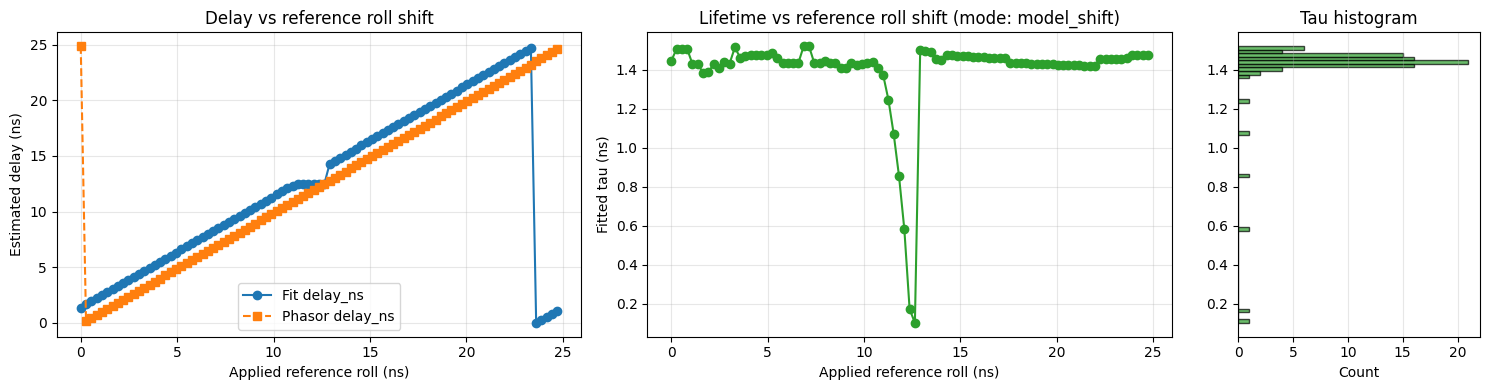

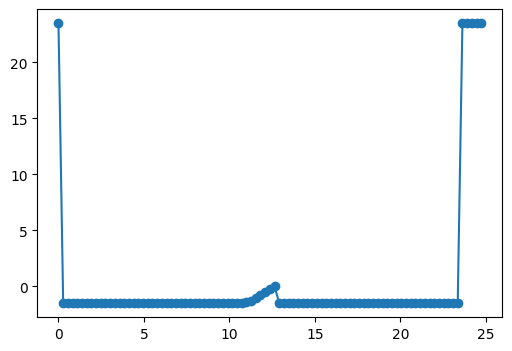

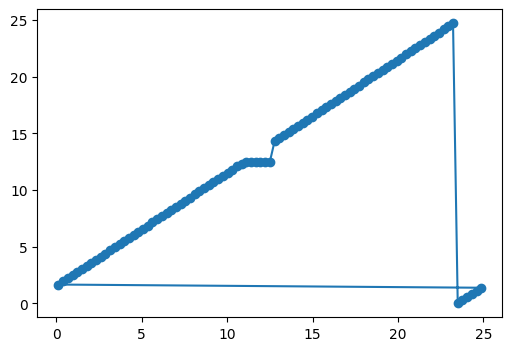

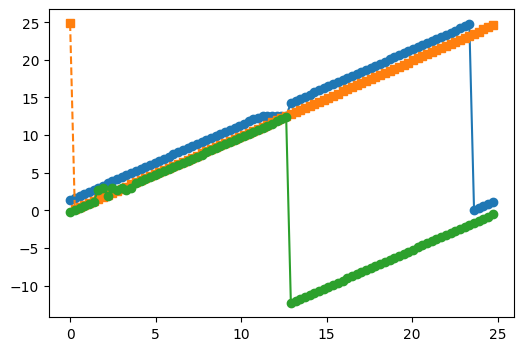

In [17]:
roll_shift_ns = scan_results_df['roll_shift_ns'].to_numpy()
dT_fit_ns = scan_results_df['dT_fit_ns'].to_numpy()
phasor_delta_ns = scan_results_df['phasor_delta_ns'].to_numpy()
tau_fit_ns = scan_results_df['tau_fit_ns'].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={'width_ratios': [1.3, 1.3, 0.6]})

axes[0].plot(roll_shift_ns, dT_fit_ns, 'o-', label='Fit delay_ns')
axes[0].plot(roll_shift_ns, phasor_delta_ns, 's--', label='Phasor delay_ns')
axes[0].set_xlabel('Applied reference roll (ns)')
axes[0].set_ylabel('Estimated delay (ns)')
axes[0].set_title('Delay vs reference roll shift')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(roll_shift_ns, tau_fit_ns, 'o-', color='tab:green')
axes[1].set_xlabel('Applied reference roll (ns)')
axes[1].set_ylabel('Fitted tau (ns)')
axes[1].set_title('Lifetime vs reference roll shift (mode: %s)' % mode)
axes[1].grid(True, alpha=0.3)

axes[2].hist(tau_fit_ns, bins='auto', orientation='horizontal', color='tab:green', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Count')
axes[2].set_title('Tau histogram')
axes[2].grid(True, axis='x', alpha=0.3)
axes[2].set_ylim(axes[1].get_ylim())

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))  
plt.plot(roll_shift_ns, phasor_delta_ns - dT_fit_ns, 'o-', label='Fit delay_ns')

plt.figure(figsize=(6, 4))  
plt.plot(phasor_delta_ns , dT_fit_ns, 'o-', label='Fit delay_ns')

plt.figure(figsize=(6, 4))
plt.plot(roll_shift_ns, dT_fit_ns, 'o-', label='Fit delay_ns')
plt.plot(roll_shift_ns, phasor_delta_ns, 's--', label='Phasor delay_ns')
plt.plot(roll_shift_ns, scan_results_df['initial_dT_bins']*dt_ns, 'o-', label='Initial delay bins')
#plt.plot(roll_shift_ns, (np.mod(scan_results_df['initial_dT_bins'].to_numpy()-1, nbin))*dt_ns, 'o-', label='Initial delay bins')

In [18]:
initial_dT_bins

np.float64(-2.0000000977516166)